# Scenario I — InceptionV3
## Melanoma Classification via Bayesian Optimisation with Tree-structured Parzen Estimator (TPE)
**Architecture:** InceptionV3  |  **Optimiser:** Optuna TPESampler (multivariate)  |  **Metric:** Validation Accuracy

## 0. Installation


In [1]:
# import subprocess, sys

# # Install PyTorch cu118 (compatible with compute capability 6.0 / P100)
# subprocess.check_call([
#     sys.executable, '-m', 'pip', 'install',
#     'torch==2.5.1+cu118',
#     'torchvision==0.20.1+cu118',
#     '--index-url', 'https://download.pytorch.org/whl/cu118',
#     '-q',
#     '--root-user-action=ignore',
#     '--disable-pip-version-check'
# ])

# print('Installation complete')
# print('IMPORTANT: restart the kernel before proceeding')

## 1. Imports, Seed & Device


In [2]:
import os, json, time, warnings, random, math
from pathlib import Path
from copy import deepcopy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import timm
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()

print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'USE_AMP : {USE_AMP}')
print(f'torch   : {torch.__version__}')
print(f'timm    : {timm.__version__}')
print(f'optuna  : {optuna.__version__}')


Device  : cuda
GPU     : Tesla P100-PCIE-16GB
VRAM    : 17.1 GB
USE_AMP : True
torch   : 2.5.1+cu118
timm    : 1.0.26
optuna  : 4.8.0


## 2. Configuration


In [3]:
# Paths
DS1_BASE  = Path('/kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset')
DS1_TRAIN = DS1_BASE / 'train'
DS1_TEST  = DS1_BASE / 'test'
DS2_BASE  = Path('/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images')
DS2_TEST  = DS2_BASE / 'melanoma_cancer_dataset' / 'test'
OUTPUT_DIR = Path('/kaggle/working/full_pipeline_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR   = OUTPUT_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

# Training config
NUM_CLASSES  = 2
NUM_WORKERS  = 4
GRAD_CLIP    = 1.0
TTA_STEPS    = 10

# ── Improvement 1: Significantly increased TPE budget ───────────────────────
N_TRIALS        = 30
TPE_EPOCHS      = 12
TPE_ES_PAT      = 3
TPE_WARMUP_TR   = 10
FINAL_EPOCHS    = 35
VIT_FINAL_EP    = 30
ENS_TRIALS      = 100

# ── Improvement 2: Pretrained ViT via timm ──────────────────────────────────
VIT_MODEL_NAME  = 'vit_small_patch16_224'
VIT_IMG_SIZE    = 224

# ── Improvement 3: Accelerated unfreeze schedule ────────────────────────────
CNN_UNFREEZE = {
    1  : 'frozen',
    5  : 'last_block',
    10 : 'last_2_blocks',
    18 : 'full',
}

ARCH_CONFIGS = {
    'densenet121': {
        'label'            : 'DenseNet-121',
        'img_size'         : 224,
        'unfreeze_schedule': CNN_UNFREEZE,
    },
    'inception_v3': {
        'label'            : 'InceptionV3',
        'img_size'         : 299,
        'unfreeze_schedule': CNN_UNFREEZE,
    },
    'xception': {
        'label'            : 'Xception',
        'img_size'         : 299,
        'unfreeze_schedule': CNN_UNFREEZE,
    },
}

MODEL_LABELS = {
    'densenet121'  : 'DenseNet-121',
    'inception_v3' : 'InceptionV3',
    'xception'     : 'Xception',
    'vit_scratch'  : 'ViT-Pretrained',
}

PAPER_REF = {
    'DenseNet-121'    : {'accuracy':0.9450, 'precision':0.9390,
                          'recall':0.9504,   'f1':0.9447},
    'InceptionV3'     : {'accuracy':0.9120, 'precision':0.9320,
                          'recall':0.8962,   'f1':0.9137},
    'Xception'        : {'accuracy':0.9380, 'precision':0.9300,
                          'recall':0.9451,   'f1':0.9375},
    'ViT-Pretrained'  : {'accuracy':0.8825, 'precision':0.9050,
                          'recall':0.8660,   'f1':0.8850},
    'Ensemble'        : {'accuracy':0.9525, 'precision':0.9420,
                          'recall':0.9622,   'f1':0.9520},
}

print('Configuration loaded successfully')
print(f'  N_TRIALS     = {N_TRIALS}  (was 20)')
print(f'  TPE_EPOCHS   = {TPE_EPOCHS}  (was 5)')
print(f'  TPE_ES_PAT   = {TPE_ES_PAT}  (was 2)')
print(f'  FINAL_EPOCHS = {FINAL_EPOCHS}  (was 30)')
print(f'  VIT_FINAL_EP = {VIT_FINAL_EP}  (was 40)')
print(f'  ENS_TRIALS   = {ENS_TRIALS}  (was 30)')
print(f'  ViT model    = {VIT_MODEL_NAME}  (was ViT-B/16 from scratch)')
print(f'  Unfreeze full at epoch {max(CNN_UNFREEZE.keys())} of {FINAL_EPOCHS}'
      f'  → {FINAL_EPOCHS - max(CNN_UNFREEZE.keys())} epoch full fine-tuning  (was 8)')
print()
print('Baseline Paper Reference:')
print(f'{"Model":<18} {"Accuracy":>10} {"Recall":>8} {"F1":>8}')
print('-' * 46)
for model, vals in PAPER_REF.items():
    print(f'{model:<18} {vals["accuracy"]:>10.2%} '
          f'{vals["recall"]:>8.2%} {vals["f1"]:>8.2%}')


Configuration loaded successfully
  N_TRIALS     = 30  (was 20)
  TPE_EPOCHS   = 12  (was 5)
  TPE_ES_PAT   = 3  (was 2)
  FINAL_EPOCHS = 35  (was 30)
  VIT_FINAL_EP = 30  (was 40)
  ENS_TRIALS   = 100  (was 30)
  ViT model    = vit_small_patch16_224  (was ViT-B/16 from scratch)
  Unfreeze full at epoch 18 of 35  → 17 epoch full fine-tuning  (was 8)

Baseline Paper Reference:
Model                Accuracy   Recall       F1
----------------------------------------------
DenseNet-121           94.50%   95.04%   94.47%
InceptionV3            91.20%   89.62%   91.37%
Xception               93.80%   94.51%   93.75%
ViT-Pretrained         88.25%   86.60%   88.50%
Ensemble               95.25%   96.22%   95.20%


## 3. Data Pipeline


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_transforms(split, img_size):
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((img_size + 24, img_size + 24)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(25),
            transforms.ColorJitter(0.15, 0.15, 0.15, 0.08),
            transforms.RandomAffine(
                0, translate=(0.1, 0.1),
                scale=(0.85, 1.15), shear=5),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),
        ])
    elif split == 'tta':
        return transforms.Compose([
            transforms.Resize((img_size + 16, img_size + 16)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])


def build_dataloaders(batch_size, img_size, val_split=0.15):
    full_ds = ImageFolder(
        DS1_TRAIN, transform=get_transforms('train', img_size))
    targets = [s[1] for s in full_ds.samples]
    cc      = [targets.count(i) for i in range(NUM_CLASSES)]

    tr_idx, vl_idx = train_test_split(
        range(len(full_ds)), test_size=val_split,
        stratify=targets, random_state=SEED)

    tr_ds   = Subset(full_ds, tr_idx)
    vl_base = ImageFolder(
        DS1_TRAIN, transform=get_transforms('val', img_size))
    vl_ds   = Subset(vl_base, vl_idx)

    tr_tgt   = np.array(targets)[tr_idx]
    class_cnt = np.bincount(tr_tgt)
    # Use sqrt inverse frequency (softer than pure inverse)
    # Pure inverse tends to over-correct; sqrt is a well-balanced compromise
    class_w  = 1.0 / np.sqrt(class_cnt.astype(float))
    class_w  = class_w / class_w.sum() * len(class_cnt)  # normalise
    sw       = class_w[tr_tgt]
    smp      = WeightedRandomSampler(
        torch.DoubleTensor(sw), len(sw) * 2, replacement=True)
    # × 2 ensures the minority class is sufficiently represented each epoch

    tr_ld = DataLoader(
        tr_ds, batch_size, sampler=smp,
        num_workers=NUM_WORKERS, pin_memory=True)
    vl_ld = DataLoader(
        vl_ds, batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True)
    te_ds = ImageFolder(
        DS1_TEST, transform=get_transforms('test', img_size))
    te_ld = DataLoader(
        te_ds, 32, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True)

    return tr_ld, vl_ld, te_ld, full_ds.classes, cc


_, _, _, CLASS_NAMES, _ = build_dataloaders(32, 224)
print(f'Class names : {CLASS_NAMES}')


Class names : ['Benign', 'Malignant']


## 4. Model Factory


In [5]:
# ── Improvement 4: CNN with a richer custom classification head ─────────────

class CNNWithHead(nn.Module):
    """CNN wrapper with custom head: GAP → BN → GELU → Dropout → Linear.
    Provides greater adaptation capacity than the default timm head.
    """
    def __init__(self, backbone, n_features, dropout, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )
        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.head(self.backbone(x))


def build_cnn(arch_name, dropout):
    """Build a pretrained CNN with a 512-dim custom classification head."""
    # num_classes=0 → timm returns features without classification head
    backbone   = timm.create_model(
        arch_name, pretrained=True,
        drop_rate=dropout, num_classes=0)
    n_features = backbone.num_features
    return CNNWithHead(backbone, n_features, dropout, NUM_CLASSES)


def apply_freeze(model, strategy):
    # Handle both CNNWithHead and plain model types
    if isinstance(model, CNNWithHead):
        params = list(model.backbone.named_parameters())
        # Classification head is always kept trainable
        for p in model.head.parameters():
            p.requires_grad_(True)
    else:
        params = list(model.named_parameters())

    total = len(params)
    for _, p in params:
        p.requires_grad_(False)

    # Selalu jaga agar layer klasifikasi (head) dan parameter afine
    # normalization layer (BatchNorm/LayerNorm: weight & bias / scale & shift)
    # tetap trainable di SEMUA tahap freeze ('frozen', 'last_block', dst).
    #
    # KEPUTUSAN DESAIN: parameter afine normalisasi sengaja tidak ikut
    # dibekukan (BatchNorm recalibration / partial fine-tuning, lih. Li et al.
    # 2017). "Frozen" di sini merujuk pada bobot konvolusi (feature extractor),
    # bukan parameter normalisasi.
    for name, p in params:
        if any(k in name for k in ('head', 'classifier', 'fc', 'last_linear', 'norm')):
            p.requires_grad_(True)

    if strategy == 'last_block':
        for i, (_, p) in enumerate(params):
            if i >= int(total * 0.85):
                p.requires_grad_(True)
    elif strategy == 'last_2_blocks':
        for i, (_, p) in enumerate(params):
            if i >= int(total * 0.70):
                p.requires_grad_(True)
    elif strategy == 'full':
        for _, p in params:
            p.requires_grad_(True)
        if isinstance(model, CNNWithHead):
            for p in model.head.parameters():
                p.requires_grad_(True)

    tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in model.parameters())
    return model, tr, tot


def progressive_unfreeze(model, epoch, schedule):
    strategy = 'frozen'
    for ep, strat in sorted(schedule.items()):
        if epoch >= ep:
            strategy = strat
    model, tr, _ = apply_freeze(model, strategy)
    return model, strategy, tr


# ── Improvement 5: Extended optimizer support including Adamax ───────────────

def build_optimizer(model, opt_name, lr, wd, layer_decay=None):
    """Build optimizer. If layer_decay is provided, applies LLRD for ViT."""
    if layer_decay is not None and hasattr(model, 'blocks'):
        # Layer-wise LR Decay (LLRD) for pretrained ViT
        depth  = len(model.blocks)
        groups = []
        # Classification head receives the full learning rate
        groups.append({'params': list(model.head.parameters()), 'lr': lr})
        groups.append({'params': list(model.norm.parameters()),  'lr': lr})
        # Each block receives progressively smaller LR towards the input
        for i, block in enumerate(reversed(model.blocks)):
            decay_factor = layer_decay ** (i + 1)
            groups.append({'params': list(block.parameters()), 'lr': lr * decay_factor})
        # Patch embedding and positional embedding
        groups.append({'params': [model.patch_embed.proj.weight,
                                   model.patch_embed.proj.bias,
                                   model.cls_token, model.pos_embed],
                       'lr': lr * (layer_decay ** (depth + 1))})
        return optim.AdamW(groups, weight_decay=wd)

    params = [p for p in model.parameters() if p.requires_grad]
    if opt_name == 'adam':
        return optim.Adam(params, lr=lr, weight_decay=wd)
    elif opt_name == 'adamax':
        return optim.Adamax(params, lr=lr, weight_decay=wd)
    return optim.AdamW(params, lr=lr, weight_decay=wd)


# ── Improvement 6: Loss function — Focal vs CE+LabelSmoothing selection ────────

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = (torch.tensor(alpha, dtype=torch.float32).to(DEVICE)
                      if alpha is not None else None)

    def forward(self, logits, targets):
        log_p  = F.log_softmax(logits, dim=1)
        ce     = F.nll_loss(log_p, targets, reduction='none')
        focal  = (1 - torch.exp(-ce)) ** self.gamma * ce
        if self.alpha is not None:
            focal = self.alpha[targets] * focal
        return focal.mean()


def build_criterion(use_focal, focal_gamma, label_smoothing, class_counts=None):
    """Select one: Focal Loss OR CrossEntropy+LabelSmoothing.
    Class weighting uses Effective Number of Samples.
    Superior to inverse-frequency weighting for moderate class imbalance.
    """
    alpha = None
    if class_counts:
        # Effective Number of Samples: (1 - beta^n) / (1 - beta)
        beta  = 0.9999
        eff   = [(1.0 - beta ** c) / (1.0 - beta) for c in class_counts]
        raw_a = [1.0 / e for e in eff]
        s     = sum(raw_a)
        # Normalise so mean weight ≈ 1.0 (improves training stability)
        alpha = [v / s * len(class_counts) for v in raw_a]

    if use_focal:
        return FocalLoss(gamma=focal_gamma, alpha=alpha)
    else:
        return nn.CrossEntropyLoss(
            label_smoothing=label_smoothing,
            weight=torch.tensor(alpha, dtype=torch.float32).to(DEVICE)
                  if alpha else None)


# ── Improvement 7: Pretrained ViT loaded from timm ──────────────────────────

def build_vit_pretrained(dropout):
    """ViT-Small/16 pretrained on ImageNet — substantially better than training from scratch."""
    model = timm.create_model(
        VIT_MODEL_NAME,
        pretrained=True,
        drop_rate=dropout,
        attn_drop_rate=dropout * 0.5,
        drop_path_rate=0.1,
        num_classes=NUM_CLASSES,
    )
    # Replace the default head with a richer two-layer variant
    in_features  = model.head.in_features
    model.head   = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(256, NUM_CLASSES),
    )
    return model


# Sanity check
_cnn = build_cnn('densenet121', 0.3).to(DEVICE)
_x   = torch.randn(2, 3, 224, 224).to(DEVICE)
_o   = _cnn(_x)
print(f'CNN output shape     : {tuple(_o.shape)}')
print(f'CNN total params     : {sum(p.numel() for p in _cnn.parameters())/1e6:.1f}M')

_vit = build_vit_pretrained(0.1).to(DEVICE)
_x2  = torch.randn(2, 3, 224, 224).to(DEVICE)
_o2  = _vit(_x2)
print(f'ViT output shape     : {tuple(_o2.shape)}')
print(f'ViT total params     : {sum(p.numel() for p in _vit.parameters())/1e6:.1f}M')
print(f'ViT model name       : {VIT_MODEL_NAME}  (pretrained=True)')

del _cnn, _vit, _x, _x2, _o, _o2
torch.cuda.empty_cache()
print('\nModel factory v2 ready')


model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

CNN output shape     : (2, 2)
CNN total params     : 7.5M


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

ViT output shape     : (2, 2)
ViT total params     : 21.8M
ViT model name       : vit_small_patch16_224  (pretrained=True)

Model factory v2 ready


## 5. Training & Evaluation Utilities


In [6]:
def train_one_epoch(model, loader, optimizer, criterion,
                    scaler, clip=None):
    model.train()
    loss_sum = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=USE_AMP):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        if clip:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), clip)
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.item() * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    loss_sum = correct = total = 0
    all_p, all_l = [], []
    crit = criterion or nn.CrossEntropyLoss()
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with autocast(enabled=USE_AMP):
            logits = model(imgs)
            loss   = crit(logits, labels)
        probs = torch.softmax(logits, 1)[:, 1]
        loss_sum += loss.item() * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
        all_p.extend(probs.cpu().numpy())
        all_l.extend(labels.cpu().numpy())
    acc = correct / total
    try:
        auc = roc_auc_score(all_l, all_p)
    except Exception:
        auc = 0.0
    return (loss_sum / total, acc, auc,
            np.array(all_l), np.array(all_p))


@torch.no_grad()
def get_probs(model, ds_root, img_size, n_tta=1):
    model.eval()
    base_ds = ImageFolder(
        ds_root, transform=get_transforms('test', img_size))
    base_ld = DataLoader(
        base_ds, 32, shuffle=False, num_workers=NUM_WORKERS)
    labels_all = []
    probs_all  = np.zeros(len(base_ds), dtype=np.float32)
    idx = 0
    for imgs, labs in base_ld:
        with autocast(enabled=USE_AMP):
            p = torch.softmax(
                model(imgs.to(DEVICE)), 1)[:, 1].cpu().numpy()
        probs_all[idx:idx + len(p)] += p
        labels_all.extend(labs.numpy())
        idx += len(p)
    for _ in range(n_tta - 1):
        ds = ImageFolder(
            ds_root, transform=get_transforms('tta', img_size))
        ld = DataLoader(
            ds, 32, shuffle=False, num_workers=NUM_WORKERS)
        idx = 0
        for imgs, _ in ld:
            with autocast(enabled=USE_AMP):
                p = torch.softmax(
                    model(imgs.to(DEVICE)), 1)[:, 1].cpu().numpy()
            probs_all[idx:idx + len(p)] += p
            idx += len(p)
    return np.array(labels_all), probs_all / n_tta


def compute_metrics(labels, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        'accuracy'  : accuracy_score(labels, preds),
        'precision' : precision_score(labels, preds, zero_division=0),
        'recall'    : recall_score(labels, preds, zero_division=0),
        'f1'        : f1_score(labels, preds, zero_division=0),
        'auc'       : roc_auc_score(labels, probs),
        'conf_mat'  : confusion_matrix(labels, preds).tolist(),
        'threshold' : float(threshold),
    }


print('Utilities ready')
print(f'  USE_AMP = {USE_AMP}')


Utilities ready
  USE_AMP = True


## 6. TPE Search + Final Training


In [7]:
def make_cnn_objective(arch_name):
    img_size = ARCH_CONFIGS[arch_name]['img_size']
    n = {'i': 0}

    def objective(trial):
        n['i'] += 1

        # ── Architecture-specific hyperparameter search space ──────────
        if arch_name == 'densenet121':
            lr  = trial.suggest_float('lr',  3e-4, 1.5e-2, log=True)
            bs  = trial.suggest_categorical('batch_size', [32, 64])
            do  = trial.suggest_float('dropout', 0.15, 0.45)
            wd  = trial.suggest_float('weight_decay', 1e-6, 5e-4, log=True)
            ui  = trial.suggest_categorical('unfreeze_init',
                      ['last_block', 'last_2_blocks'])
            opt = trial.suggest_categorical('optimizer_name',
                      ['adam', 'adamw', 'adamax'])
            uf  = trial.suggest_categorical('use_focal', [True, False])
            fg  = trial.suggest_float('focal_gamma', 0.5, 2.5)
            ls  = trial.suggest_float('label_smoothing', 0.00, 0.12)
            sc  = trial.suggest_categorical('scheduler_type', ['cosine', 'onecycle'])

        elif arch_name == 'inception_v3':
            lr  = trial.suggest_float('lr',  2e-4, 8e-3, log=True)
            bs  = trial.suggest_categorical('batch_size', [32, 64])
            do  = trial.suggest_float('dropout', 0.20, 0.55)
            wd  = trial.suggest_float('weight_decay', 1e-6, 5e-4, log=True)
            opt = trial.suggest_categorical('optimizer_name',
                      ['adam', 'adamw', 'adamax'])
            uf  = trial.suggest_categorical('use_focal', [True, False])
            fg  = trial.suggest_float('focal_gamma', 0.5, 2.5)
            ls  = trial.suggest_float('label_smoothing', 0.02, 0.15)
            # HIPOTESIS (terbukti pada DenseNet-121): 'unfreeze_init' &
            # 'scheduler_type' TIDAK ikut dicari TPE. Keduanya dipakai
            # seperti final training original (selalu 'frozen' +
            # CosineAnnealingLR), karena kombinasi ini terbukti memberi
            # hasil terbaik pada eksperimen sebelumnya.
            ui  = 'frozen'
            sc  = 'cosine'

        else:  # xception
            lr  = trial.suggest_float('lr',  1e-4, 5e-3, log=True)
            bs  = trial.suggest_categorical('batch_size', [32, 64])
            do  = trial.suggest_float('dropout', 0.25, 0.55)
            wd  = trial.suggest_float('weight_decay', 1e-6, 1e-3, log=True)
            ui  = trial.suggest_categorical('unfreeze_init',
                      ['last_block', 'last_2_blocks'])
            opt = trial.suggest_categorical('optimizer_name',
                      ['adam', 'adamw', 'adamax'])
            uf  = trial.suggest_categorical('use_focal', [True, False])
            fg  = trial.suggest_float('focal_gamma', 0.5, 2.5)
            ls  = trial.suggest_float('label_smoothing', 0.03, 0.15)
            sc  = trial.suggest_categorical('scheduler_type', ['cosine', 'onecycle'])

        print(f'  Trial {n["i"]:>2}/{N_TRIALS} '
              f'lr={lr:.2e} bs={bs} do={do:.2f} '
              f'opt={opt} frz={ui} '
              f'focal={uf} sc={sc}',
              end=' -> ')
        try:
            model = build_cnn(arch_name, do).to(DEVICE)
            model, _, _ = apply_freeze(model, ui)
            tr_ld, vl_ld, _, _, cc = build_dataloaders(bs, img_size)
            optimizer = build_optimizer(model, opt, lr, wd)
            criterion = build_criterion(uf, fg, ls, cc)

            if sc == 'onecycle':
                scheduler = optim.lr_scheduler.OneCycleLR(
                    optimizer, max_lr=lr,
                    steps_per_epoch=len(tr_ld),
                    epochs=TPE_EPOCHS,
                    pct_start=0.3, div_factor=10.0,
                    final_div_factor=100.0)
                step_per_batch = True
            else:
                scheduler = optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=TPE_EPOCHS, eta_min=lr * 0.01)
                step_per_batch = False

            scaler   = GradScaler(enabled=USE_AMP)
            best_acc = 0.0
            no_impr  = 0

            for ep in range(TPE_EPOCHS):
                if step_per_batch:
                    # OneCycleLR requires scheduler.step() after every batch
                    model.train()
                    for xb, yb in tr_ld:
                        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                        optimizer.zero_grad()
                        with autocast(enabled=USE_AMP):
                            loss = criterion(model(xb), yb)
                        scaler.scale(loss).backward()
                        scaler.unscale_(optimizer)
                        nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                        scaler.step(optimizer)
                        scaler.update()
                        scheduler.step()
                else:
                    train_one_epoch(model, tr_ld, optimizer, criterion,
                                    scaler, GRAD_CLIP)

                _, val_acc, _, _, _ = evaluate(model, vl_ld, criterion)
                if not step_per_batch:
                    scheduler.step()

                if val_acc > best_acc:
                    best_acc = val_acc
                    no_impr  = 0
                else:
                    no_impr += 1
                if no_impr >= TPE_ES_PAT:
                    break

            print(f'acc={best_acc:.4f}')
            del model, optimizer, scheduler, scaler, tr_ld, vl_ld
            torch.cuda.empty_cache()
            return best_acc
        except Exception as e:
            print(f'ERROR: {e}')
            torch.cuda.empty_cache()
            return 0.0
    return objective


def run_final_cnn(arch_name, bp):
    """Training final dengan progressive unfreeze.

    PERBAIKAN untuk InceptionV3 (mengatasi training collapse di fase
    'last_2_blocks'/'full' — val_auc anjlok dari ~0.96 ke ~0.24 pada run
    sebelumnya):

    1. LR_SCALE diturunkan untuk 'last_2_blocks' dan 'full' — InceptionV3
       memiliki BatchNorm dengan banyak parameter trainable sekaligus
       (14.8M & 22.8M) sehingga lebih sensitif terhadap LR besar saat
       banyak layer di-unfreeze bersamaan dibanding DenseNet/Xception.

    2. Safety rollback: jika val_acc pada suatu epoch turun > ROLLBACK_DROP
       dari best_val_acc TERAKHIR (indikasi training collapse/divergence),
       bobot model di-restore ke checkpoint terbaik sebelum lanjut ke epoch
       berikutnya, dan optimizer/scheduler dibuat ulang dengan LR yang
       diperkecil (LR_DECAY_ON_ROLLBACK). Ini mencegah model "tersesat" di
       wilayah loss yang buruk untuk sisa epoch.
    """
    img_size = ARCH_CONFIGS[arch_name]['img_size']
    schedule = ARCH_CONFIGS[arch_name]['unfreeze_schedule']

    model = build_cnn(arch_name, bp['dropout'])
    model, _, _ = apply_freeze(model, 'frozen')
    model = model.to(DEVICE)

    tr_ld, vl_ld, _, _, cc = build_dataloaders(bp['batch_size'], img_size)
    optimizer = build_optimizer(model, bp['optimizer_name'],
                                bp['lr'], bp['weight_decay'])
    criterion = build_criterion(bp['use_focal'], bp['focal_gamma'],
                                bp['label_smoothing'], cc)
    scaler = GradScaler(enabled=USE_AMP)

    # CosineAnnealingLR from scratch — more predictable, easy to reset per unfreeze phase
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=4, eta_min=bp['lr'] * 0.1)

    # ── LR_SCALE: diturunkan untuk last_2_blocks & full ─────────────────
    LR_SCALE = {
        'frozen'       : 1.00,   # head only
        'last_block'   : 0.20,   # 20% dari LR awal
        'last_2_blocks': 0.04,   # PERBAIKAN: dari 0.08 -> 0.04
        'full'         : 0.01,   # PERBAIKAN: dari 0.02 -> 0.01
    }

    # ── Safety rollback config ──────────────────────────────────────────
    ROLLBACK_DROP       = 0.05   # turun > 5 poin acc dari best -> rollback
    LR_DECAY_ON_ROLLBACK = 0.5   # setiap rollback, LR fase ini dikalikan 0.5
    rollback_count = {}          # hitung rollback per strategi (cap di 2x)

    best_val_acc = 0.0
    best_state   = None
    best_epoch   = 0
    prev_strat   = None
    vl_labels_best = None
    vl_probs_best  = None
    cur_lr = bp['lr']
    history = {'train_loss':[], 'val_loss':[],
               'train_acc':[], 'val_acc':[],
               'val_auc':[], 'freeze_strategy':[]}

    def _build_optimizer_scheduler(model, cur_strat, cur_lr, remaining):
        opt_name = bp['optimizer_name']
        wd       = bp['weight_decay']
        if cur_strat == 'full' and isinstance(model, CNNWithHead):
            # Differential LR: head menerima LR 5x lebih besar dari backbone
            param_groups = [
                {'params': list(model.head.parameters()),     'lr': cur_lr * 5.0},
                {'params': list(model.backbone.parameters()), 'lr': cur_lr},
            ]
            if opt_name == 'adam':
                opt = optim.Adam(param_groups, weight_decay=wd)
            elif opt_name == 'adamax':
                opt = optim.Adamax(param_groups, weight_decay=wd)
            else:
                opt = optim.AdamW(param_groups, weight_decay=wd)
        else:
            opt = build_optimizer(model, opt_name, cur_lr, wd)

        sch = optim.lr_scheduler.CosineAnnealingLR(
            opt, T_max=max(remaining, 1), eta_min=cur_lr * 5e-3)
        return opt, sch

    for epoch in range(1, FINAL_EPOCHS + 1):
        t_ep = time.time()
        model, cur_strat, n_tr = progressive_unfreeze(model, epoch, schedule)

        if cur_strat != prev_strat:
            cur_lr = bp['lr'] * LR_SCALE.get(cur_strat, 0.01)
            print(f'  Epoch {epoch}: strategi -> {cur_strat} '
                  f'({n_tr:,} params trainable), '
                  f'lr={cur_lr:.2e}  (scale={LR_SCALE.get(cur_strat, 0.01):.2f})')

            remaining = FINAL_EPOCHS - epoch + 1
            optimizer, scheduler = _build_optimizer_scheduler(
                model, cur_strat, cur_lr, remaining)
            prev_strat = cur_strat
            rollback_count.setdefault(cur_strat, 0)

        tr_loss, tr_acc = train_one_epoch(
            model, tr_ld, optimizer, criterion, scaler, GRAD_CLIP)
        vl_loss, vl_acc, vl_auc, vl_labels, vl_probs = evaluate(
            model, vl_ld, criterion)
        scheduler.step()

        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(vl_acc)
        history['val_auc'].append(vl_auc)
        history['freeze_strategy'].append(cur_strat)

        rolled_back = False
        if (best_state is not None and
                (best_val_acc - vl_acc) > ROLLBACK_DROP and
                rollback_count.get(cur_strat, 0) < 2):
            # Training collapse terdeteksi -> restore checkpoint terbaik,
            # turunkan LR fase ini, lanjutkan training.
            model.load_state_dict(best_state)
            rollback_count[cur_strat] += 1
            cur_lr = cur_lr * LR_DECAY_ON_ROLLBACK
            remaining = FINAL_EPOCHS - epoch
            optimizer, scheduler = _build_optimizer_scheduler(
                model, cur_strat, cur_lr, remaining)
            rolled_back = True

        if vl_acc > best_val_acc:
            best_val_acc   = vl_acc
            best_state     = deepcopy(model.state_dict())
            best_epoch     = epoch
            vl_labels_best = vl_labels
            vl_probs_best  = vl_probs
            mark = ' <- best'
        else:
            mark = ' <- ROLLBACK' if rolled_back else ''

        cur_lr_print = optimizer.param_groups[0]['lr']
        print(f'  Ep {epoch:>2}/{FINAL_EPOCHS} '
              f'loss {tr_loss:.4f}/{vl_loss:.4f} '
              f'acc {tr_acc:.4f}/{vl_acc:.4f} '
              f'auc {vl_auc:.4f} '
              f'lr={cur_lr_print:.2e} '
              f'{time.time()-t_ep:.0f}s{mark}')

    model.load_state_dict(best_state)
    print(f'  Best weights from epoch {best_epoch} '
          f'(val acc={best_val_acc:.4f})')
    return model, vl_labels_best, vl_probs_best, history, best_epoch


## 7. Run InceptionV3


In [8]:
# ── Initialise result containers ────────────────────────────────────────────
all_models      = {}
all_probs_ds1   = {}
all_val_probs   = {}
all_metrics_ds1 = {}
all_val_labels  = None
ds1_labels      = None
tpe_best_params = {}

arch_name = 'inception_v3'
arch_cfg  = ARCH_CONFIGS[arch_name]
label     = arch_cfg['label']      # 'InceptionV3'
img_size  = arch_cfg['img_size']

import time

print()
print('=' * 70)
print(f'  {label} | {img_size}x{img_size} | '
      f'TPE {N_TRIALS} trials x {TPE_EPOCHS} epoch  '
      f'[multivariate TPE, startup={TPE_WARMUP_TR}]')
print('=' * 70)

sampler = optuna.samplers.TPESampler(
    seed=SEED,
    n_startup_trials=TPE_WARMUP_TR,
    multivariate=True,
    warn_independent_sampling=False,
)
study = optuna.create_study(
    direction='maximize', sampler=sampler,
    study_name=f'tpe_{arch_name}')
study.optimize(
    make_cnn_objective(arch_name),
    n_trials=N_TRIALS, show_progress_bar=False)

bp = dict(study.best_trial.params)
tpe_best_params[arch_name] = {**bp, 'best_val_acc': study.best_value}

print(f'  TPE complete | best val acc: {study.best_value:.4f}')
print(f'  Best params : {bp}')

with open(OUTPUT_DIR / f'tpe_{arch_name}.json', 'w') as f:
    json.dump(tpe_best_params[arch_name], f, indent=2)

print(f'\n  Final Training — {FINAL_EPOCHS} epochs')
model, vl_labels, vl_probs, history, best_ep = run_final_cnn(arch_name, bp)

all_val_probs[arch_name] = vl_probs
all_val_labels = vl_labels

torch.save({
    'arch'       : arch_name,
    'state_dict' : model.state_dict(),
    'best_params': bp,
    'best_epoch' : best_ep,
    'history'    : history,
    'img_size'   : img_size,
}, CKPT_DIR / f'{arch_name}_best.pth')

labels, probs = get_probs(model, DS1_TEST, img_size, TTA_STEPS)
m = compute_metrics(labels, probs)

all_models[arch_name]      = model
all_probs_ds1[arch_name]   = probs
all_metrics_ds1[arch_name] = m
ds1_labels = labels

paper = PAPER_REF[label]
print(f'\n  {label} Results (TTA ×{TTA_STEPS}) vs. Baseline Paper:')
print(f'  {"Metric":<12} {"Ours":>8} {"Paper":>8} {"Delta":>9}')
print('  ' + '-' * 40)
for k in ['accuracy', 'precision', 'recall', 'f1']:
    d = m[k] - paper[k]
    sign = 'OK' if d >= 0 else 'BELOW'
    print(f'  {k:<12} {m[k]:>8.4f} '
          f'{paper[k]:>8.4f} {d:>+9.4f}  {sign}')

torch.cuda.empty_cache()

# Save probabilities and labels for use in Scenario II notebook
import numpy as np
np.save(OUTPUT_DIR / f'probs_ds1_{arch_name}.npy', probs)
np.save(OUTPUT_DIR / f'val_probs_{arch_name}.npy', vl_probs)
np.save(OUTPUT_DIR / f'val_labels.npy', vl_labels)
np.save(OUTPUT_DIR / f'ds1_labels.npy', labels)
print(f'\nProbabilities saved to {OUTPUT_DIR}')



  InceptionV3 | 299x299 | TPE 30 trials x 12 epoch  [multivariate TPE, startup=10]
  Trial  1/30 lr=7.96e-04 bs=32 do=0.41 opt=adamax frz=frozen focal=False sc=cosine -> 

model.safetensors:   0%|          | 0.00/95.5M [00:00<?, ?B/s]

acc=0.8462
  Trial  2/30 lr=4.31e-03 bs=32 do=0.26 opt=adam frz=frozen focal=True sc=cosine -> acc=0.8535
  Trial  3/30 lr=1.08e-03 bs=32 do=0.38 opt=adamw frz=frozen focal=False sc=cosine -> acc=0.8597
  Trial  4/30 lr=6.15e-04 bs=64 do=0.35 opt=adamax frz=frozen focal=False sc=cosine -> acc=0.8462
  Trial  5/30 lr=1.50e-03 bs=64 do=0.47 opt=adamax frz=frozen focal=False sc=cosine -> acc=0.8434
  Trial  6/30 lr=8.39e-04 bs=64 do=0.32 opt=adamax frz=frozen focal=False sc=cosine -> acc=0.8418
  Trial  7/30 lr=2.04e-04 bs=32 do=0.46 opt=adamw frz=frozen focal=True sc=cosine -> acc=0.8423
  Trial  8/30 lr=6.30e-04 bs=64 do=0.42 opt=adamax frz=frozen focal=True sc=cosine -> acc=0.8316
  Trial  9/30 lr=1.38e-03 bs=32 do=0.24 opt=adam frz=frozen focal=True sc=cosine -> acc=0.8547
  Trial 10/30 lr=4.65e-04 bs=64 do=0.26 opt=adamax frz=frozen focal=True sc=cosine -> acc=0.8496
  Trial 11/30 lr=1.68e-03 bs=32 do=0.33 opt=adamw frz=frozen focal=False sc=cosine -> acc=0.8440
  Trial 12/30 lr=1.06

## 6b. Training & Validation Loss Curve

Visualisasi `train_loss` vs `val_loss` dan `train_acc` vs `val_acc` per epoch.


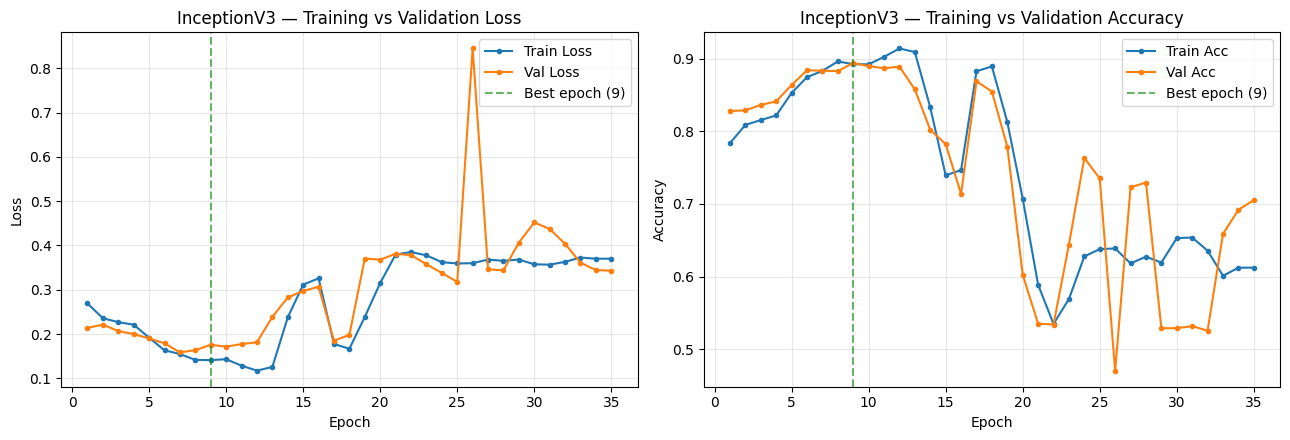

In [9]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', ms=3)
axes[0].plot(epochs_range, history['val_loss'],   label='Val Loss',   marker='o', ms=3)
axes[0].axvline(best_ep, color='green', ls='--', alpha=0.6, label=f'Best epoch ({best_ep})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title(f'{label} — Training vs Validation Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history['train_acc'], label='Train Acc', marker='o', ms=3)
axes[1].plot(epochs_range, history['val_acc'],   label='Val Acc',   marker='o', ms=3)
axes[1].axvline(best_ep, color='green', ls='--', alpha=0.6, label=f'Best epoch ({best_ep})')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title(f'{label} — Training vs Validation Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / f"loss_curve_{arch_name}.png", dpi=150)
plt.show()


## 8. TPE Analysis — Convergence & Hyperparameter Importance

This section visualises the Bayesian Optimisation process for **InceptionV3**:

- **Panel A** — TPE convergence curve: individual trial accuracy and best-so-far trajectory. The shaded region marks the random startup phase before the surrogate model activates.
- **Panel B** — Hyperparameter importance scores computed via **fANOVA**. Importance quantifies the fraction of val-accuracy variance attributable to each hyperparameter across all trials.
- **Panel C** — Best hyperparameter configuration selected by TPE.

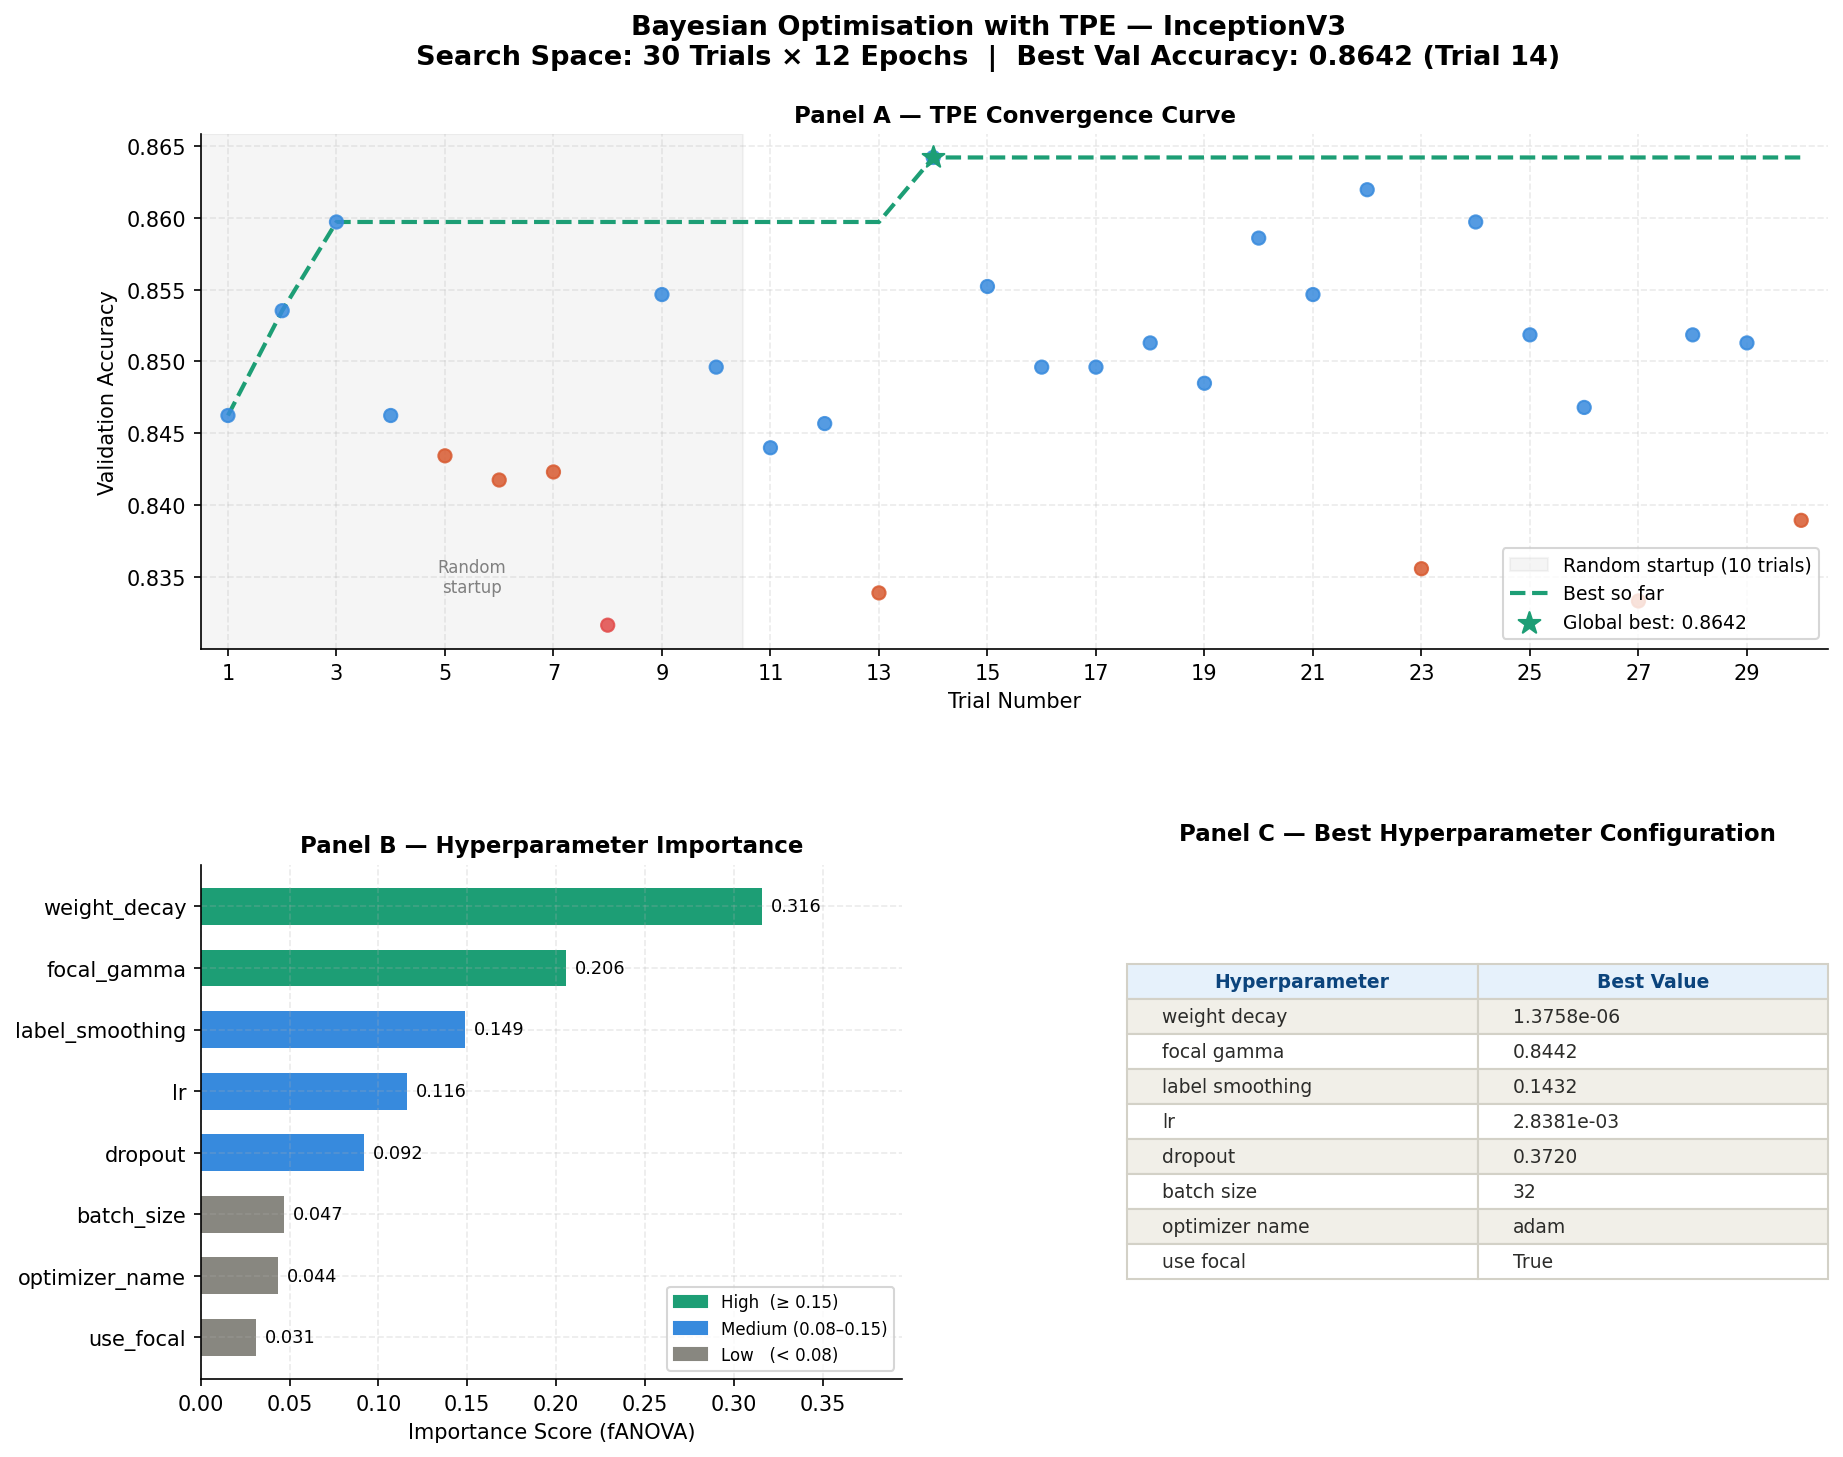

Figure saved: /kaggle/working/full_pipeline_results/tpe_analysis_inception_v3.png

Hyperparameter Importance (InceptionV3) — fANOVA:
  Hyperparameter         Importance  Rank
  ------------------------------------------
  weight_decay               0.3159  #1  ███████████████
  focal_gamma                0.2058  #2  ██████████
  label_smoothing            0.1488  #3  ███████
  lr                         0.1160  #4  █████
  dropout                    0.0920  #5  ████
  batch_size                 0.0467  #6  ██
  optimizer_name             0.0437  #7  ██
  use_focal                  0.0312  #8  █


In [10]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import optuna

matplotlib.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.25,
    'grid.linestyle'   : '--',
    'figure.dpi'       : 150,
})

arch_name_viz = arch_name   # set from the run cell
label_viz     = MODEL_LABELS[arch_name_viz]

# ── 1. Retrieve trial data ────────────────────────────────────────────────────
trial_values  = [t.value for t in study.trials if t.value is not None]
n_trials      = len(trial_values)
best_so_far   = [max(trial_values[:i+1]) for i in range(n_trials)]
trial_nums    = list(range(1, n_trials + 1))
best_val      = study.best_value
best_trial_n  = study.best_trial.number + 1

# ── 2. HP Importance via fANOVA ───────────────────────────────────────────────
importance    = optuna.importance.get_param_importances(
    study,
    evaluator=optuna.importance.FanovaImportanceEvaluator())
hp_names      = list(importance.keys())
hp_scores     = list(importance.values())
# Sort descending
sorted_pairs  = sorted(zip(hp_scores, hp_names), reverse=True)
hp_scores_s   = [p[0] for p in sorted_pairs]
hp_names_s    = [p[1] for p in sorted_pairs]

# ── 3. Figure layout ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    f'Bayesian Optimisation with TPE — {label_viz}\n'
    f'Search Space: {n_trials} Trials × {TPE_EPOCHS} Epochs  |  '
    f'Best Val Accuracy: {best_val:.4f} (Trial {best_trial_n})',
    fontsize=13, fontweight='bold', y=0.98)

gs  = gridspec.GridSpec(2, 2, figure=fig,
                        hspace=0.42, wspace=0.32,
                        top=0.90, bottom=0.07)

# colour palette
C_TRIAL  = '#378ADD'
C_BEST   = '#1D9E75'
C_WORST  = '#E24B4A'
C_START  = 'rgba(136,135,128,0.07)'

# ────────────────────────────────────────────────────────────────────────────
# Panel A — TPE Convergence
# ────────────────────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :])   # full-width top row

ax1.axvspan(0.5, TPE_WARMUP_TR + 0.5,
            alpha=0.08, color='gray',
            label=f'Random startup ({TPE_WARMUP_TR} trials)')

# Individual trial dots
colors_dot = [C_WORST if v == min(trial_values) else
              ('#D85A30' if v < np.percentile(trial_values, 25) else C_TRIAL)
              for v in trial_values]
ax1.scatter(trial_nums, trial_values,
            c=colors_dot, s=40, zorder=4, alpha=0.85)

# Best-so-far line
ax1.plot(trial_nums, best_so_far,
         color=C_BEST, linewidth=2, linestyle='--',
         label='Best so far', zorder=3)

# Highlight global best
ax1.scatter([best_trial_n], [best_val],
            color=C_BEST, s=120, zorder=5,
            marker='*', label=f'Global best: {best_val:.4f}')

# Startup region label
ax1.text(TPE_WARMUP_TR / 2 + 0.5, min(trial_values) + 0.002,
         'Random\nstartup', fontsize=8, color='gray',
         ha='center', va='bottom')

ax1.set_xlabel('Trial Number', fontsize=10)
ax1.set_ylabel('Validation Accuracy', fontsize=10)
ax1.set_title('Panel A — TPE Convergence Curve', fontsize=11, fontweight='bold')
ax1.set_xlim(0.5, n_trials + 0.5)
ax1.set_xticks(range(1, n_trials + 1, 2))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax1.legend(fontsize=9, loc='lower right')

# ────────────────────────────────────────────────────────────────────────────
# Panel B — Hyperparameter Importance (fANOVA)
# ────────────────────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])

bar_colors = ['#1D9E75' if s >= 0.15 else
              '#378ADD' if s >= 0.08 else
              '#888780' for s in hp_scores_s]

bars = ax2.barh(hp_names_s, hp_scores_s,
                color=bar_colors, height=0.6, edgecolor='none')

for bar, score in zip(bars, hp_scores_s):
    ax2.text(score + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{score:.3f}', va='center', ha='left', fontsize=8.5)

ax2.set_xlabel('Importance Score (fANOVA)', fontsize=10)
ax2.set_title('Panel B — Hyperparameter Importance', fontsize=11, fontweight='bold')
ax2.set_xlim(0, max(hp_scores_s) * 1.25)
ax2.invert_yaxis()

legend_patches = [
    mpatches.Patch(color='#1D9E75', label='High  (≥ 0.15)'),
    mpatches.Patch(color='#378ADD', label='Medium (0.08–0.15)'),
    mpatches.Patch(color='#888780', label='Low   (< 0.08)'),
]
ax2.legend(handles=legend_patches, fontsize=8, loc='lower right')

# ────────────────────────────────────────────────────────────────────────────
# Panel C — Best Hyperparameter Values (table)
# ────────────────────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')

bp_disp = tpe_best_params[arch_name_viz]
rows = []
fmt  = {
    'lr'              : lambda v: f'{v:.4e}',
    'batch_size'      : lambda v: str(int(v)),
    'dropout'         : lambda v: f'{v:.4f}',
    'weight_decay'    : lambda v: f'{v:.4e}',
    'unfreeze_init'   : lambda v: str(v),
    'optimizer_name'  : lambda v: str(v),
    'use_focal'       : lambda v: str(v),
    'focal_gamma'     : lambda v: f'{v:.4f}',
    'label_smoothing' : lambda v: f'{v:.4f}',
    'scheduler_type'  : lambda v: str(v),
    'warmup_epochs'   : lambda v: str(int(v)),
    'layer_decay'     : lambda v: f'{v:.4f}',
}
for k, v in bp_disp.items():
    if k == 'best_val_acc':
        continue
    disp_v = fmt[k](v) if k in fmt else str(v)
    rows.append([k.replace('_', ' '), disp_v])

# Sort by importance if available
imp_rank = {k: i for i, k in enumerate(hp_names_s)}
rows.sort(key=lambda r: imp_rank.get(r[0].replace(' ', '_'), 99))

table = ax3.table(
    cellText  = rows,
    colLabels = ['Hyperparameter', 'Best Value'],
    loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#D3D1C7')
    if r == 0:
        cell.set_facecolor('#E6F1FB')
        cell.set_text_props(fontweight='bold', color='#0C447C')
    else:
        cell.set_facecolor('#FFFFFF' if r % 2 == 0 else '#F1EFE8')
        cell.set_text_props(color='#2C2C2A')

ax3.set_title('Panel C — Best Hyperparameter Configuration',
              fontsize=11, fontweight='bold', pad=12)

# ── Save ─────────────────────────────────────────────────────────────────────
out_path = OUTPUT_DIR / f'tpe_analysis_{arch_name_viz}.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"Figure saved: {out_path}")

# ── Print importance table to console ────────────────────────────────────────
print(f"\nHyperparameter Importance ({label_viz}) — fANOVA:")
print(f"  {'Hyperparameter':<22} {'Importance':>10}  {'Rank'}")
print("  " + "-" * 42)
for rank, (name, score) in enumerate(zip(hp_names_s, hp_scores_s), 1):
    bar = '█' * int(score * 50)
    print(f"  {name:<22} {score:>10.4f}  #{rank}  {bar}")


In [11]:
import numpy as np

ds2_labels, ds2_probs = get_probs(model, DS2_TEST, 299, TTA_STEPS)
np.save(OUTPUT_DIR / 'probs_ds2_inception_v3.npy', ds2_probs)
np.save(OUTPUT_DIR / 'ds2_labels.npy',             ds2_labels)

m = compute_metrics(ds2_labels, ds2_probs)
d1 = all_metrics_ds1['inception_v3']

print(f"\nInceptionV3 — DS1 vs DS2 Generalization:")
print(f"  {'Metric':<12} {'DS1':>8} {'DS2':>8} {'Delta':>10}")
print("  " + "-" * 42)
for k in ['accuracy', 'precision', 'recall', 'f1']:
    diff = m[k] - d1[k]
    print(f"  {k:<12} {d1[k]:>8.4f} {m[k]:>8.4f} {diff:>+10.4f}  {'▼' if diff<0 else '▲'}")

print(f"\nSaved: probs_ds2_inception_v3.npy")
print(f"Saved: ds2_labels.npy")


InceptionV3 — DS1 vs DS2 Generalization:
  Metric            DS1      DS2      Delta
  ------------------------------------------
  accuracy       0.8955   0.9150    +0.0195  ▲
  precision      0.9510   0.9521    +0.0011  ▲
  recall         0.8340   0.8740    +0.0400  ▲
  f1             0.8887   0.9114    +0.0227  ▲

Saved: probs_ds2_inception_v3.npy
Saved: ds2_labels.npy



DS1
  TP: 834  FP: 43
  FN: 166  TN: 957

DS2
  TP: 437  FP: 22
  FN: 63  TN: 478


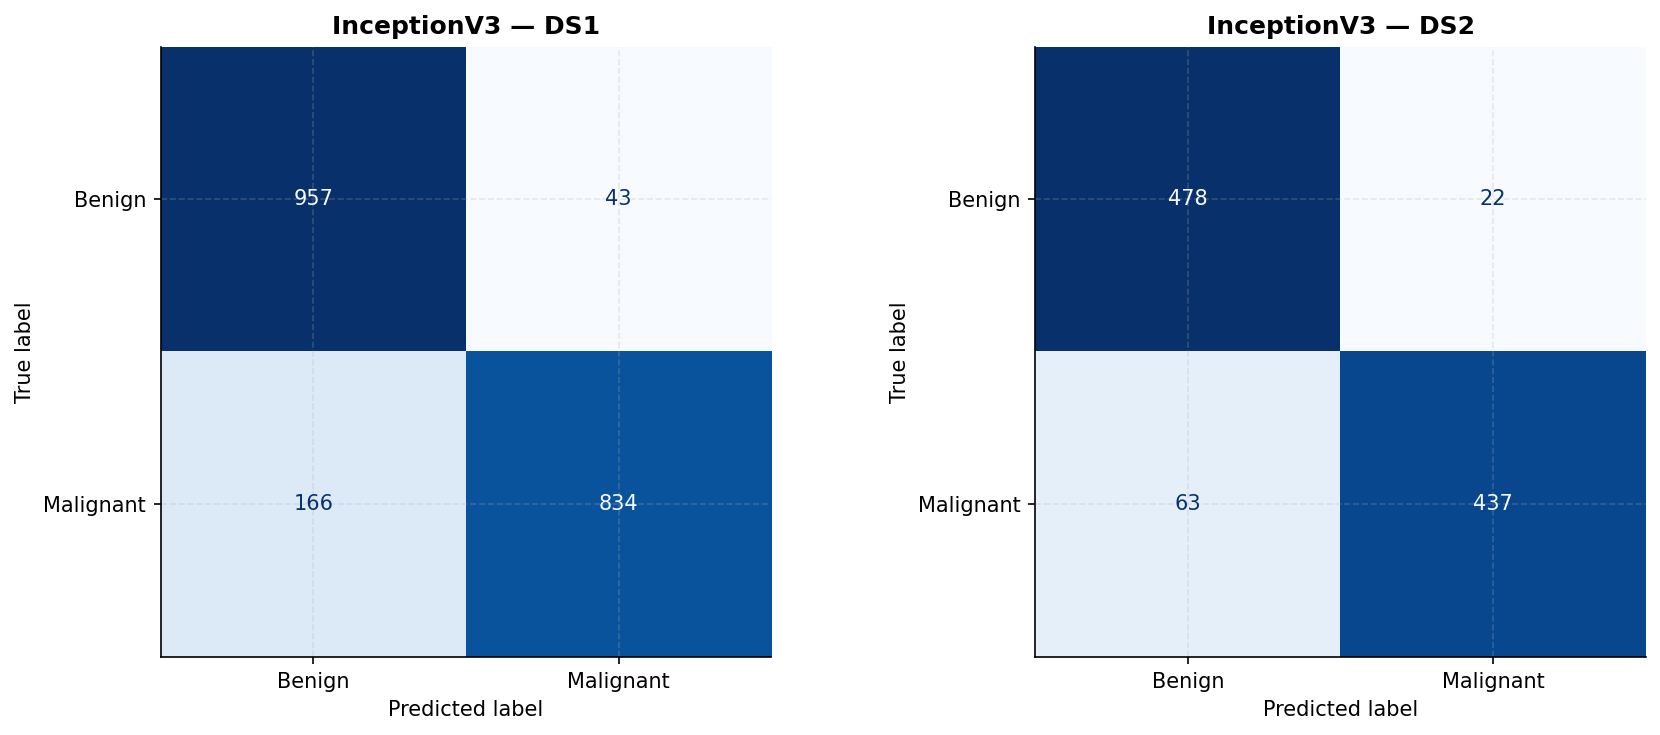

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

probs_ds1  = all_probs_ds1[arch_name]
labels_ds1 = ds1_labels
probs_ds2  = ds2_probs
labels_ds2 = ds2_labels

preds_ds1 = (probs_ds1 >= 0.5).astype(int)
preds_ds2 = (probs_ds2 >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (labels, preds, title) in zip(axes, [
    (labels_ds1, preds_ds1, "DS1"),
    (labels_ds2, preds_ds2, "DS2"),
]):
    cm = confusion_matrix(labels, preds)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Benign", "Malignant"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(f"InceptionV3 — {title}", fontweight="bold")

    tn, fp, fn, tp = cm.ravel()
    print(f"\n{title}")
    print(f"  TP: {tp}  FP: {fp}")
    print(f"  FN: {fn}  TN: {tn}")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_inceptionv3.png", dpi=150)
plt.show()
